In [1]:
from EncoderDecoder.utils import loadData
from EncoderDecoder.utils import latex_species
import matplotlib.pyplot as plt
import logging
logging.disable(logging.CRITICAL)

In [2]:
import os

#add the root directory
os.chdir('../')

In [12]:
path_data = "data-files/"
filename = "Tr1d2PV0to1_RMSprop_250_major_s4-AE-date_01Aug2026-hour_17h05_Malik-CFLF-2022"

general_dataset_type = "Malik"
dataset_type = "CFLF-2022"

loader = loadData(filename)

id = loader.metadata["training_id"]

training, validation = loader.loadCurves()

extraVars, PV, PVsource = loader.getManifoldParameters(path_data, "CFLF-2022")

C:\Users\Admin\Documents\PhD-ULB\Programming\EncoderDecoder\src\EncoderDecoder\models.py:214: UserWarning: No extra manifold variable is not available because 'self.extra_manifold_variables' is empty.
  warnings.warn("No extra manifold variable is not available because 'self.extra_manifold_variables' is empty.", UserWarning)


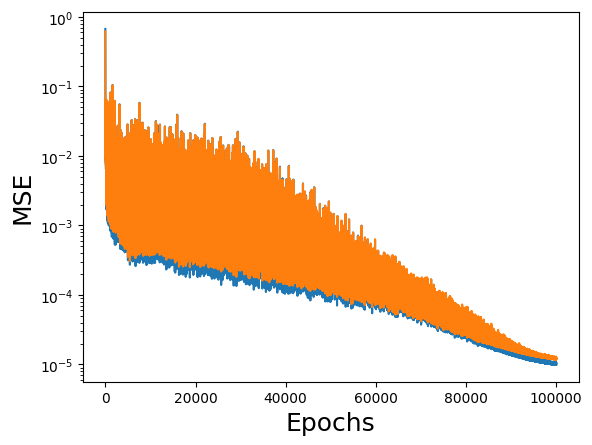

In [4]:
plt.plot(training)
plt.plot(validation)
plt.yscale("log")
plt.xlabel("Epochs", fontsize = 18)
plt.ylabel("MSE", fontsize = 18)
plt.show()

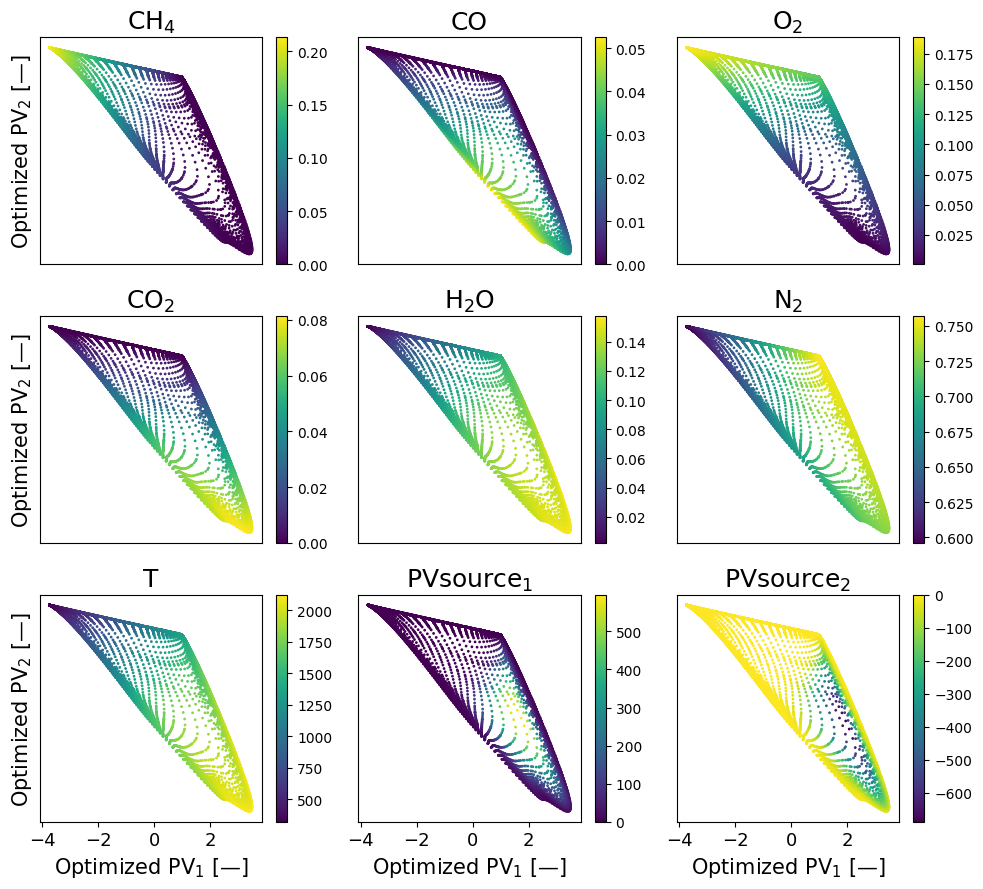

In [13]:
rows, cols = 3, 3

species = ["CH4", "CO", "O2", "CO2", "H2O", "N2"]
keys = species + ["T", "PVsource1", "PVsource2"] #"T"

save = True
pathSave = "C:/Users/Admin/Documents/PhD-ULB/Figures/2026-PV-optimization-for-practical-ROM/2022-Malik/Visualizations/f-PV manifolds/2 optimized PVs/"
name = f"f-PV_opt ({id}) - colored by major species"

# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(rows, cols, figsize=(10, 9))
axes = axes.flatten()

for i, key in enumerate(keys):

    ax = axes[i]

    # Color variable
    if key in species:
        dataColor = loader.getSpecies(path_data, general_dataset_type, dataset_type, key)

    elif key == "T":
        dataColor = loader.getVariable(path_data, general_dataset_type, dataset_type, "T")

    elif key == "PVsource1":
        dataColor = PVsource[:,0]

    elif key == "PVsource2":
        dataColor = PVsource[:,1]

    # Scatter plot
    sc = ax.scatter(
        PV[:, 0],
        PV[:, 1],
        c=dataColor,
        cmap="viridis",
        s=1
    )

    # x-axis formatting
    if i >= len(keys) - cols:
        ax.set_xlabel("Optimized PV$_1$ [\u2014]", fontsize=15)
        ax.tick_params(axis="x", labelsize=13)
    else:
        ax.set_xticks([])

    # y-axis formatting
    if i % cols == 0:
        ax.set_ylabel(f"Optimized PV$_2$ [\u2014]", fontsize=15)

    ax.set_yticks([])

    # Nice title formatting
    title = (
        latex_species(key)
    )

    ax.set_title(title, fontsize=18)

    # Individual colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(labelsize=10)

# Disable unused axes
for j in range(len(keys), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

if save:
    plt.savefig(pathSave + name, dpi=300, bbox_inches="tight")

plt.show()

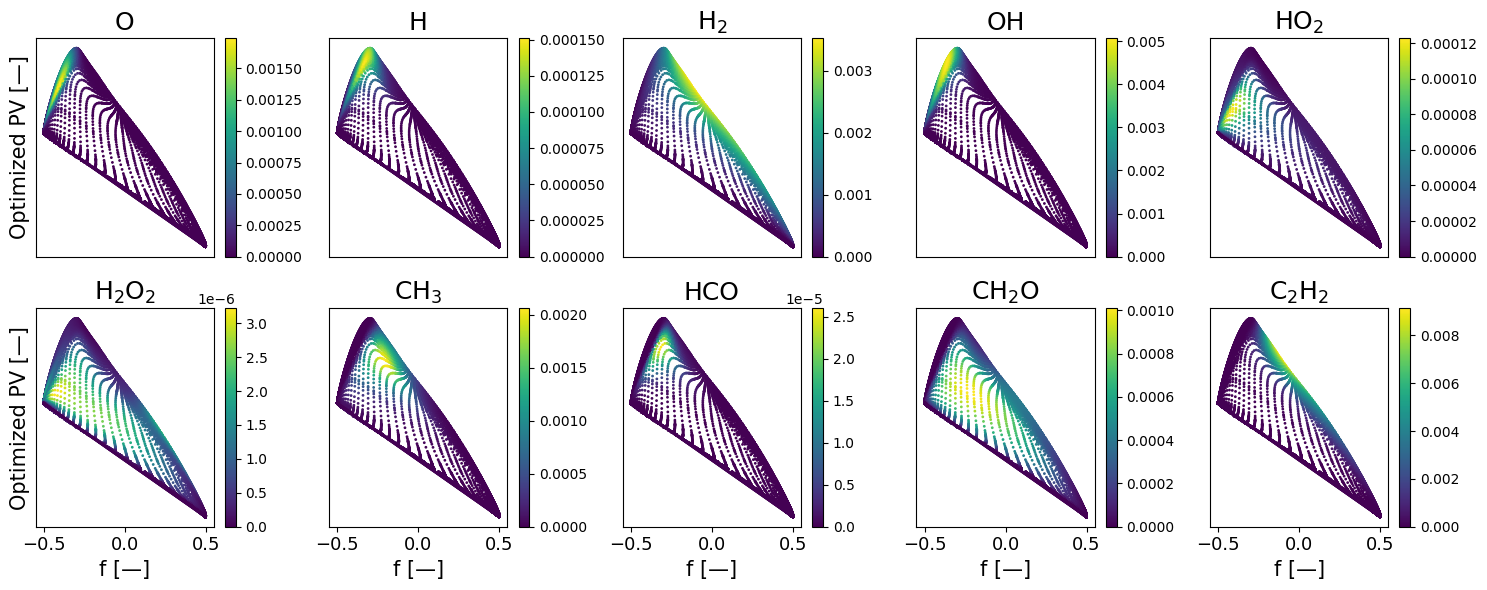

In [19]:
rows, cols = 2, 5

species = ["O", "H", "H2", "OH", "HO2", "H2O2", "CH3", "HCO", "CH2O", "C2H2"]
keys = species + [] #"T"

# Mixture fraction
mixture_fraction = extraVars

save = True
pathSave = "C:/Users/Admin/Documents/PhD-ULB/Figures/2026-PV-optimization-for-practical-ROM/2022-Malik/Visualizations/f-PV manifolds/Optimized/"
name = f"f-PV_opt ({id}) - colored by minor species"

# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
axes = axes.flatten()

for i, key in enumerate(keys):

    ax = axes[i]

    # Color variable
    if key in species:
        dataColor = loader.getSpecies(path_data, general_dataset_type, dataset_type, key)

    elif key == "T":
        dataColor = loader.getVariable(path_data, general_dataset_type, dataset_type, "T")

    elif key == "PVsource":
        dataColor = PVsource

    # Scatter plot
    sc = ax.scatter(
        mixture_fraction,
        PV,
        c=dataColor,
        cmap="viridis",
        s=1
    )

    # x-axis formatting
    if i >= len(keys) - cols:
        ax.set_xlabel("f [\u2014]", fontsize=15)
        ax.tick_params(axis="x", labelsize=13)
    else:
        ax.set_xticks([])

    # y-axis formatting
    if i % cols == 0:
        ax.set_ylabel(f"Optimized PV [\u2014]", fontsize=15)

    ax.set_yticks([])

    # Nice title formatting
    title = (
        latex_species(key)
    )

    ax.set_title(title, fontsize=18)

    # Individual colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(labelsize=10)

# Disable unused axes
for j in range(len(keys), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

if save:
    plt.savefig(pathSave + name, dpi=300, bbox_inches="tight")

plt.show()